# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Muhammad Dzaky Haidar | 5054251039 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [38]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA

sns.set_style('whitegrid')

In [39]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('data.csv')
print(df.dtypes)
print(df.isnull().sum()[df.isnull().sum() > 0])
df.describe()

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


/tmp/ipykernel_3272/2357528137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='diagnosis', data=df, palette='Set2')


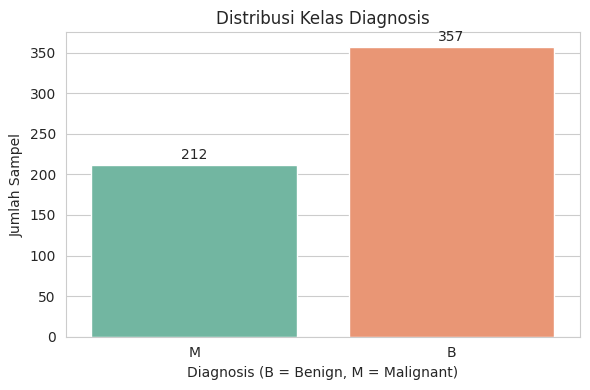

Proporsi Target (%):
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [40]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(6,4))
ax = sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Distribusi Kelas Diagnosis')
plt.xlabel('Diagnosis (B = Benign, M = Malignant)')
plt.ylabel('Jumlah Sampel')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() /2., p.get_height()), ha='center', va='baseline', fontsize=10, xytext=(0,4), textcoords='offset points')

plt.tight_layout()
plt.show()

print("Proporsi Target (%):")
print(df['diagnosis'].value_counts(normalize=True) * 100)


/tmp/ipykernel_3272/1646532711.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3272/1646532711.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3272/1646532711.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3272/1646532711.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

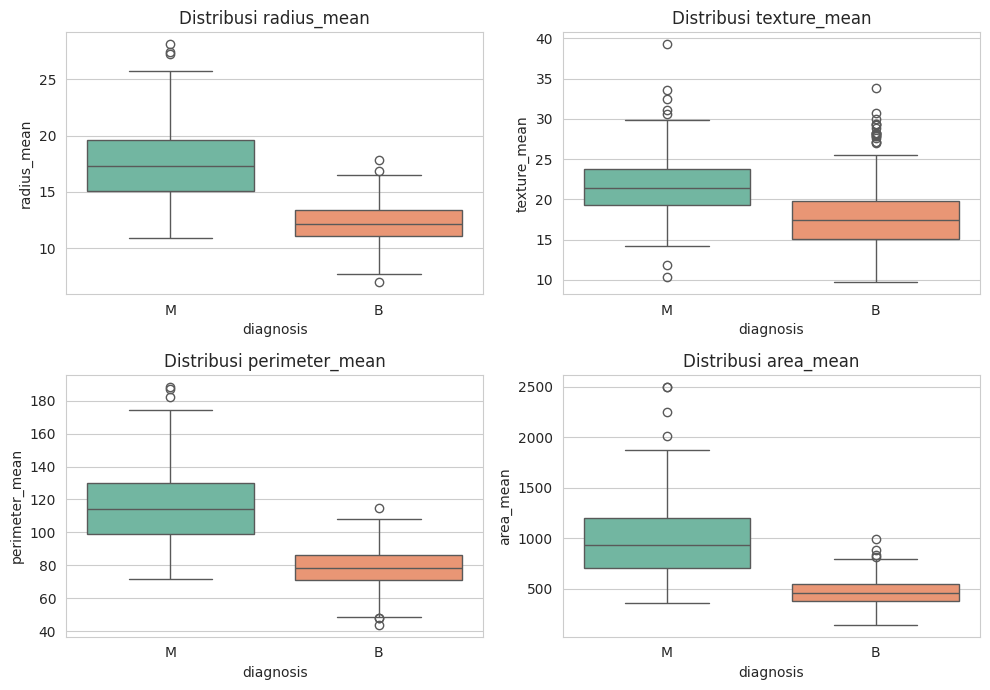

In [41]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.

features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

fig, axes = plt.subplots(2,2,figsize=(10,7))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [42]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

cols_to_drop = [col for col in ['Unnamed: 32', 'id'] if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(df.isnull().sum()[df.isnull().sum() > 0])
print(df.isnull().sum().sum())

Series([], dtype: int64)
0


In [43]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

df['diagnosis'] = df['diagnosis'].map({'B' : 0, 'M':1})

print("Distribusi kelas setelah encoding:")
print(df['diagnosis'].value_counts())
print("\nProporsi kelas (%):")
print(df['diagnosis'].value_counts(normalize=True) * 100)


Distribusi kelas setelah encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64

Proporsi kelas (%):
diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


In [44]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape[0])
print(X_test.shape[0])

print((y_train.value_counts(normalize=True) * 100).to_dict())
print((y_test.value_counts(normalize=True) * 100).to_dict())


455
114
{0: 62.637362637362635, 1: 37.362637362637365}
{0: 63.1578947368421, 1: 36.84210526315789}


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [45]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"- Rata-rata X_train_scaled: {X_train_scaled.mean():.4f}")
print(f"- Standar Deviasi X_train_scaled: {X_train_scaled.std():.4f}")
print(f"- Shape X_train_scaled: {X_train_scaled.shape}")
print(f"- Shape X_test_scaled : {X_test_scaled.shape}")

- Rata-rata X_train_scaled: 0.0000
- Standar Deviasi X_train_scaled: 1.0000
- Shape X_train_scaled: (455, 30)
- Shape X_test_scaled : (114, 30)


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [46]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).

model_linear = SVC(kernel='linear', C=1.0, random_state=42)
model_linear.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [57]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_linear = model_linear.predict(X_test_scaled)
print(y_pred_linear)

[0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [58]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.

model_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_rbf.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [59]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_rbf = model_rbf.predict(X_test_scaled)
print(y_pred_rbf)

[0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 1 1]


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [60]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
c_values = [0.01, 0.1, 1, 10, 100]
models_c = {}

for c in c_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    models_c[c] = model


In [61]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
history = {'C': [], 'train_acc': [], 'test_acc': []}

for c, model in models_c.items():
    tr_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    te_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    history['C'].append(c)
    history['train_acc'].append(tr_acc)
    history['test_acc'].append(te_acc)

pd.DataFrame(history)


,C,train_acc,test_acc
0,0.01,0.626374,0.631579
1,0.10,0.953846,0.947368
2,1.00,0.986813,0.973684
3,10.00,0.989011,0.973684
4,100.00,1.000000,0.964912


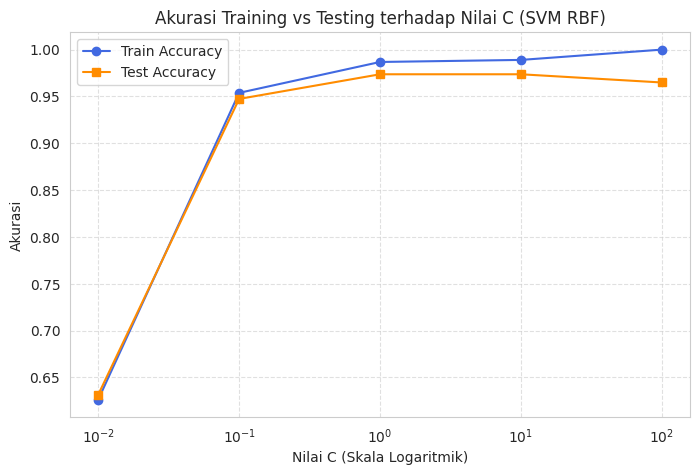

In [62]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
plt.figure(figsize=(8, 5))
plt.plot(history['C'], history['train_acc'], marker='o', label='Train Accuracy', color='royalblue')
plt.plot(history['C'], history['test_acc'], marker='s', label='Test Accuracy', color='darkorange')

plt.xscale('log')
plt.title('Akurasi Training vs Testing terhadap Nilai C (SVM RBF)')
plt.xlabel('Nilai C (Skala Logaritmik)')
plt.ylabel('Akurasi')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


# 4. Evaluasi Model

In [63]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
df_eval = pd.DataFrame({
    'Kernel': ['Linear', 'RBF'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rbf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rbf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf)
    ]
})

df_eval


,Kernel,Accuracy,Precision,Recall,F1-Score
0,Linear,0.964912,1.0,0.904762,0.950000
1,RBF,0.973684,1.0,0.928571,0.962963


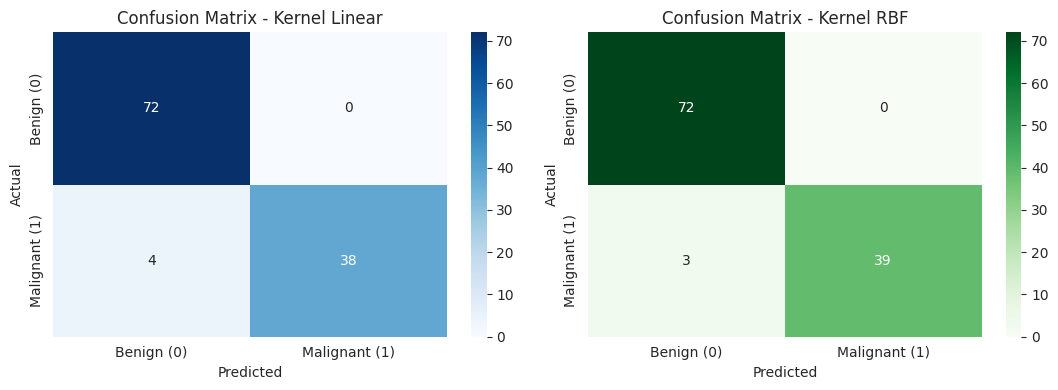

In [64]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion Matrix Linear
cm_linear = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[0].set_title('Confusion Matrix - Kernel Linear')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix RBF
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[1].set_title('Confusion Matrix - Kernel RBF')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [65]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
df_sv = pd.DataFrame({
    'Kernel': ['Linear', 'RBF'],
    'Support Vectors Benign (0)': [model_linear.n_support_[0], model_rbf.n_support_[0]],
    'Support Vectors Malignant (1)': [model_linear.n_support_[1], model_rbf.n_support_[1]],
    'Total Support Vectors': [sum(model_linear.n_support_), sum(model_rbf.n_support_)]
})

df_sv


,Kernel,Support Vectors Benign (0),Support Vectors Malignant (1),Total Support Vectors
0,Linear,19,19,38
1,RBF,50,57,107


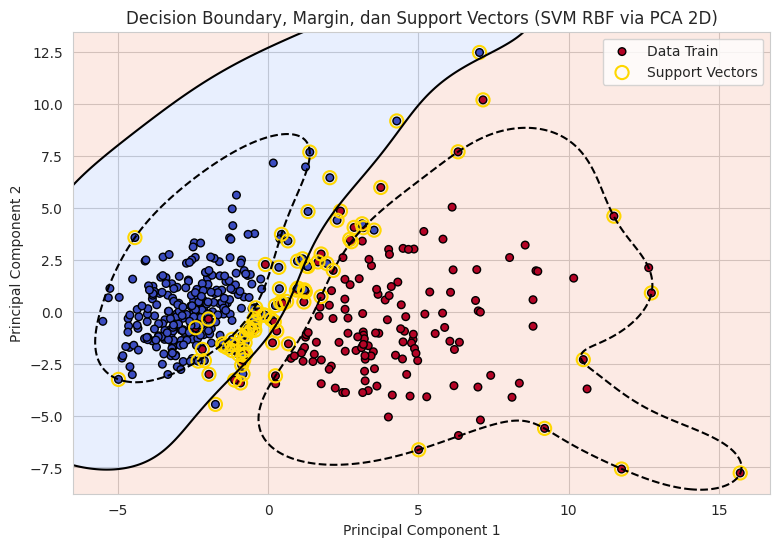

In [66]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.

# 1. Reduksi dimensi fitur X_train_scaled ke 2D
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2. Latih model RBF pada data proyeksi 2D
model_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_2d.fit(X_train_pca, y_train)

# 3. Meshgrid batas keputusan
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# 4. Decision function untuk kontur hyperplane
Z = model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 5. Visualisasi
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z > 0, alpha=0.2, cmap='coolwarm')
plt.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k')

# Titik data training
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=30, label='Data Train')

# Highlight Support Vectors
plt.scatter(model_2d.support_vectors_[:, 0], model_2d.support_vectors_[:, 1],
            s=90, facecolors='none', edgecolors='gold', linewidths=1.5, label='Support Vectors')

plt.title('Decision Boundary, Margin, dan Support Vectors (SVM RBF via PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


# 5. Analisis

#### **1. Perbandingan Performa Kernel Linear vs RBF**
* **Hasil Evaluasi:**
  * **Kernel Linear:** Akurasi = **96.49%**, Precision = **100%**, Recall = **90.48%**, F1-Score = **95.00%** (38 True Positive, 4 False Negative).
  * **Kernel RBF:** Akurasi = **97.37%**, Precision = **100%**, Recall = **92.86%**, F1-Score = **96.30%** (39 True Positive, 3 False Negative).
* **Signifikansi:**
  * Performa kedua kernel tidak berbeda drastis (selisih akurasi hanya ~0.88% atau tepatnya 1 sampel uji), namun kernel RBF unggul sedikit pada metrik *Recall* dan *F1-Score*.
* **Kaitan dengan Hasil EDA:**
  * Pada tahap EDA (boxplot), fitur-fitur morfologi utama seperti `radius_mean`, `perimeter_mean`, dan `area_mean` sudah memperlihatkan pemisahan kelas yang cukup tegas (*linearly separable*). Hal inilah yang menyebabkan kernel Linear sudah mampu memberikan akurasi baseline yang sangat tinggi (>96%).
  * Namun, pada fitur tekstur dan kehalusan (seperti `texture_mean` dan `smoothness_mean`), terdapat area tumpang tindih (*overlap*) antar kelas. Kernel RBF memproyeksikan fitur ke dimensi lebih tinggi sehingga mampu memodelkan batas non-linear pada data yang tumpang tindih tersebut secara lebih akurat.

---

#### **2. Pengaruh Parameter Regularisasi ($C$) dan Gejala Overfitting**
* **Hasil Eksperimen Nilai $C$ (Kernel RBF):**
  * $C = 0.01$: Train Acc = **62.64%**, Test Acc = **63.16%** $\rightarrow$ **Underfitting parah**. Margin terlalu lebar dan penalti kesalahan terlalu longgar, sehingga model hanya memprediksi kelas mayoritas (Benign ~62.7%).
  * $C = 0.10$: Train Acc = **95.38%**, Test Acc = **94.74%** $\rightarrow$ Model mulai belajar memisahkan data dengan baik.
  * $C = 1.00$: Train Acc = **98.68%**, Test Acc = **97.37%** $\rightarrow$ **Titik Trade-off Optimal**. Gap antara train dan test sangat kecil (~1.31%) dengan performa uji tertinggi.
  * $C = 10.00$: Train Acc = **98.90%**, Test Acc = **97.37%** $\rightarrow$ Akurasi testing stagnan.
  * $C = 100.00$: Train Acc = **100.00%**, Test Acc = **96.49%** $\rightarrow$ **Mulai Overfitting**.
* **Ciri-ciri Overfitting pada Grafik:**
  * Gejala overfitting mulai terlihat jelas pada nilai **$C = 100$**.
  * Ciri visualnya: Kurva akurasi training terus meningkat hingga mencapai nilai sempurna (**100%**), namun kurva akurasi testing justru **mengalami penurunan** dari 97.37% ke 96.49%.
  * Hal ini terjadi karena nilai $C$ yang terlalu besar memberikan penalti kesalahan yang sangat kaku, memaksa margin menjadi sangat sempit untuk mengakomodasi seluruh titik latih (menghafal data latih) sehingga kehilangan kemampuan generalisasi pada data baru.

---

#### **3. Analisis Jumlah Support Vectors (Linear vs RBF)**
* **Perbandingan Jumlah Support Vector:**
  * **Kernel Linear:** **38 Support Vectors** (19 Benign, 19 Malignant) $\rightarrow$ merepresentasikan hanya **8.35%** dari total 455 data training.
  * **Kernel RBF:** **107 Support Vectors** (50 Benign, 57 Malignant) $\rightarrow$ merepresentasikan **23.51%** dari total 455 data training.
* **Hubungan dengan Kompleksitas Batas Keputusan (*Decision Boundary*):**
  * Jumlah support vector berbanding lurus dengan fleksibilitas dan kompleksitas model.
  * **Kernel Linear** menghasilkan batas keputusan berupa bidang datar (*hyperplane* kaku/sederhana), sehingga hanya titik-titik data yang berada tepat di tepi perbatasan pemisah saja yang diangkat menjadi support vector (jumlahnya sedikit).
  * **Kernel RBF** membentuk batas keputusan kontur melengkung (*curved non-linear boundary*) yang jauh lebih fleksibel. Untuk menopang bentuk kurva non-linear tersebut di ruang berdimensi tinggi, model memerlukan jauh lebih banyak titik acuan (support vector meningkat hampir 3 kali lipat).


# 6. Kesimpulan dan Saran

#### **Kesimpulan**
* **Performa Model:** Model SVM berhasil melakukan klasifikasi diagnosis kanker payudara dengan tingkat akurasi sangat tinggi (>96%). Kernel RBF memberikan performa terbaik dengan Akurasi **97.37%**, Precision **100%**, dan F1-Score **96.30%**, sedikit melampaui kernel Linear (**96.49%**).
* **Pentingnya Preprocessing:** Penghapusan kolom artefak (`Unnamed: 32`) dan identifier (`id`), penanganan *stratified split* (62.7% : 37.3%), serta *StandardScaler* terbukti krusial untuk mencegah dominasi fitur berskala besar (`area_worst`) pada kalkulasi jarak SVM tanpa menyebabkan *data leakage*.
* **Pengaruh Regularisasi ($C$):** 
  * Nilai $C$ mengontrol trade-off bias-variance secara signifikan. Nilai $C = 1.0$ merupakan konfigurasi optimal untuk generalisasi.
  * Nilai $C$ yang terlalu kecil ($C=0.01$) memicu *underfitting*, sedangkan $C$ yang terlalu besar ($C=100$) memicu *overfitting* (akurasi latih 100%, akurasi uji turun).
* **Karakteristik Boundary:** Kernel Linear menghasilkan model yang lebih efisien dan *compact* (hanya butuh 38 support vectors), sedangkan RBF membutuhkan 107 support vectors untuk membentuk batas keputusan non-linear yang lebih adaptif.

---

#### **Saran untuk Pengembangan Selanjutnya**
* **Hyperparameter Tuning Lanjutan:** Menggunakan metode pencarian sistematis seperti `GridSearchCV` atau `RandomizedSearchCV` untuk melakukan tuning gabungan (*joint tuning*) antara parameter `C` dan `gamma` secara simultan pada kernel RBF.
* **Eksplorasi Kernel Lain:** Menguji performa kernel lain seperti **Polynomial Kernel** (dengan variasi derajat `degree=2` atau `3`) dan **Sigmoid Kernel** untuk melihat apakah kontur polinomial dapat menyaingi kernel RBF dengan kompleksitas komputasi yang lebih efisien.
* **Feature Selection / Dimensionality Reduction:** Menerapkan seleksi fitur berdasarkan korelasi atau *Recursive Feature Elimination* (RFE), mengingat beberapa fitur memiliki multikolinearitas tinggi (seperti `radius`, `perimeter`, dan `area` yang saling berikatan kuat).
* **Validasi Silang (Cross-Validation):** Menggunakan *Stratified K-Fold Cross Validation* (misal $K=5$ atau $10$) agar estimasi performa model lebih objektif dan tidak bergantung hanya pada satu kali pembagian train-test split.
